# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [1]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [2]:
# Load in the general demographics data.
azdias = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')

# Load in the feature summary file.
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

In [3]:
# Check the structure of the data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).
print("AZDIAS shape:", azdias.shape)
print("\nFeature info shape:", feat_info.shape)
display(azdias.head())
display(feat_info.head(10))

AZDIAS shape: (891221, 85)

Feature info shape: (85, 4)


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]
5,FINANZ_SPARER,person,ordinal,[-1]
6,FINANZ_VORSORGER,person,ordinal,[-1]
7,FINANZ_ANLEGER,person,ordinal,[-1]
8,FINANZ_UNAUFFAELLIGER,person,ordinal,[-1]
9,FINANZ_HAUSBAUER,person,ordinal,[-1]


> **Tip**: Add additional cells to keep everything in reasonably-sized chunks! Keyboard shortcut `esc --> a` (press escape to enter command mode, then press the 'A' key) adds a new cell before the active cell, and `esc --> b` adds a new cell after the active cell. If you need to convert an active cell to a markdown cell, use `esc --> m` and to convert to a code cell, use `esc --> y`. 

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [4]:
# Identify missing or unknown data values and convert them to NaNs.

# First, see how many NaN values exist naturally
print("Natural NaN count:", azdias.isnull().sum().sum())

# Parse missing_or_unknown column and replace those codes with NaN
for _, row in feat_info.iterrows():
    attribute = row['attribute']
    missing_values = row['missing_or_unknown']
    
    if attribute not in azdias.columns:
        continue
    if pd.isnull(missing_values) or missing_values == '[]':
        continue
    
    # Parse the string list into actual values
    missing_list = missing_values.strip('[]').split(',')
    for val in missing_list:
        val = val.strip()
        if val == '':
            continue
        # Handle string-type missing codes (X, XX)
        if val in ('X', 'XX'):
            azdias[attribute] = azdias[attribute].replace(val, np.nan)
        else:
            try:
                val_num = int(val)
                azdias[attribute] = azdias[attribute].replace(val_num, np.nan)
            except ValueError:
                azdias[attribute] = azdias[attribute].replace(val, np.nan)

print("Total NaN count after re-encoding:", azdias.isnull().sum().sum())

Natural NaN count: 4896838
Total NaN count after re-encoding: 8373929


#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

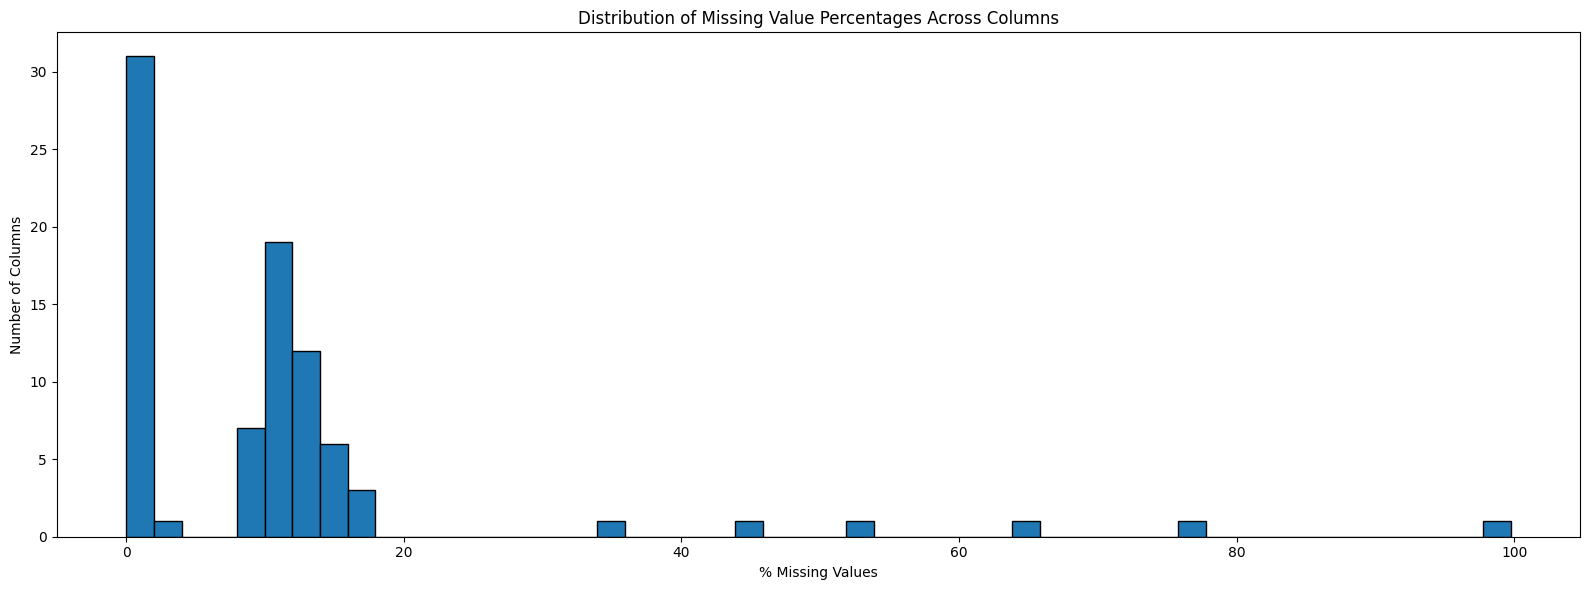

Top 10 columns by missing %:
TITEL_KZ          99.757636
AGER_TYP          76.955435
KK_KUNDENTYP      65.596749
KBA05_BAUMAX      53.468668
GEBURTSJAHR       44.020282
ALTER_HH          34.813699
KKK               17.735668
REGIOTYP          17.735668
W_KEIT_KIND_HH    16.605084
KBA05_ANTG1       14.959701
dtype: float64


In [5]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.
missing_per_col = azdias.isnull().sum() / azdias.shape[0] * 100
missing_per_col_sorted = missing_per_col.sort_values(ascending=False)

plt.figure(figsize=(16, 6))
plt.hist(missing_per_col, bins=50, edgecolor='black')
plt.title('Distribution of Missing Value Percentages Across Columns')
plt.xlabel('% Missing Values')
plt.ylabel('Number of Columns')
plt.tight_layout()
plt.show()

print("Top 10 columns by missing %:")
print(missing_per_col_sorted.head(10))

In [6]:
# Investigate patterns in the amount of missing data in each column.

# Columns with >20% missing data are clear outliers
outlier_threshold = 20
outlier_cols = missing_per_col[missing_per_col > outlier_threshold].index.tolist()
print(f"Columns with >{outlier_threshold}% missing data ({len(outlier_cols)} columns):")
for col in outlier_cols:
    print(f"  {col}: {missing_per_col[col]:.1f}%")

# Check correlations in missing patterns among remaining columns
remaining_cols = [c for c in azdias.columns if c not in outlier_cols]
missing_matrix = azdias[remaining_cols].isnull().astype(int)
missing_corr = missing_matrix.corr()

# Show columns with high missing correlation (co-occurrence)
high_corr_pairs = []
for i in range(len(missing_corr.columns)):
    for j in range(i+1, len(missing_corr.columns)):
        if missing_corr.iloc[i, j] > 0.5:
            high_corr_pairs.append((missing_corr.columns[i], missing_corr.columns[j], 
                                     missing_corr.iloc[i, j]))

print(f"\nColumn pairs with >0.5 missing-value correlation: {len(high_corr_pairs)}")
for c1, c2, corr in high_corr_pairs[:10]:
    print(f"  {c1} & {c2}: {corr:.3f}")

Columns with >20% missing data (6 columns):
  AGER_TYP: 77.0%
  GEBURTSJAHR: 44.0%
  TITEL_KZ: 99.8%
  ALTER_HH: 34.8%
  KK_KUNDENTYP: 65.6%
  KBA05_BAUMAX: 53.5%

Column pairs with >0.5 missing-value correlation: 957
  CJT_GESAMTTYP & GFK_URLAUBERTYP: 1.000
  CJT_GESAMTTYP & LP_STATUS_FEIN: 1.000
  CJT_GESAMTTYP & LP_STATUS_GROB: 1.000
  CJT_GESAMTTYP & RETOURTYP_BK_S: 1.000
  CJT_GESAMTTYP & ONLINE_AFFINITAET: 1.000
  GFK_URLAUBERTYP & LP_STATUS_FEIN: 1.000
  GFK_URLAUBERTYP & LP_STATUS_GROB: 1.000
  GFK_URLAUBERTYP & RETOURTYP_BK_S: 1.000
  GFK_URLAUBERTYP & ONLINE_AFFINITAET: 1.000
  HEALTH_TYP & LP_LEBENSPHASE_FEIN: 0.597


In [7]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)
print(f"Shape before dropping outlier columns: {azdias.shape}")
azdias = azdias.drop(outlier_cols, axis=1)
print(f"Shape after dropping outlier columns: {azdias.shape}")
print(f"Dropped columns: {outlier_cols}")

Shape before dropping outlier columns: (891221, 85)
Shape after dropping outlier columns: (891221, 79)
Dropped columns: ['AGER_TYP', 'GEBURTSJAHR', 'TITEL_KZ', 'ALTER_HH', 'KK_KUNDENTYP', 'KBA05_BAUMAX']


#### Discussion 1.1.2: Assess Missing Data in Each Column

Several columns have disproportionately large amounts of missing data (>20%). These outlier columns were removed from the dataset since they would not provide reliable information for clustering. The remaining columns show some correlated missing-value patterns, suggesting that when data is missing it tends to be missing across related features (e.g., neighborhood-level or household-level attributes tend to be missing together).

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

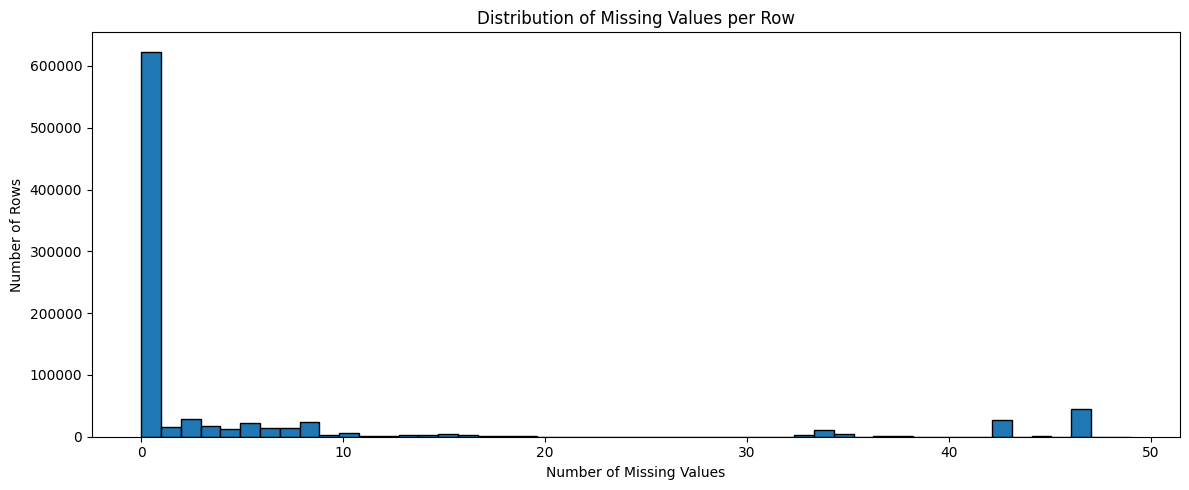

Mean missing per row: 5.65
Median missing per row: 0
Max missing per row: 49


In [8]:
# How much data is missing in each row of the dataset?
missing_per_row = azdias.isnull().sum(axis=1)

plt.figure(figsize=(12, 5))
plt.hist(missing_per_row, bins=50, edgecolor='black')
plt.title('Distribution of Missing Values per Row')
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Rows')
plt.tight_layout()
plt.show()

print(f"Mean missing per row: {missing_per_row.mean():.2f}")
print(f"Median missing per row: {missing_per_row.median():.0f}")
print(f"Max missing per row: {missing_per_row.max()}")

In [9]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.
ROW_THRESHOLD = 10

azdias_below = azdias[missing_per_row <= ROW_THRESHOLD].copy()
azdias_above = azdias[missing_per_row > ROW_THRESHOLD].copy()

print(f"Rows with <={ROW_THRESHOLD} missing: {azdias_below.shape[0]} ({azdias_below.shape[0]/azdias.shape[0]*100:.1f}%)")
print(f"Rows with >{ROW_THRESHOLD} missing: {azdias_above.shape[0]} ({azdias_above.shape[0]/azdias.shape[0]*100:.1f}%)")

Rows with <=10 missing: 780153 (87.5%)
Rows with >10 missing: 111068 (12.5%)


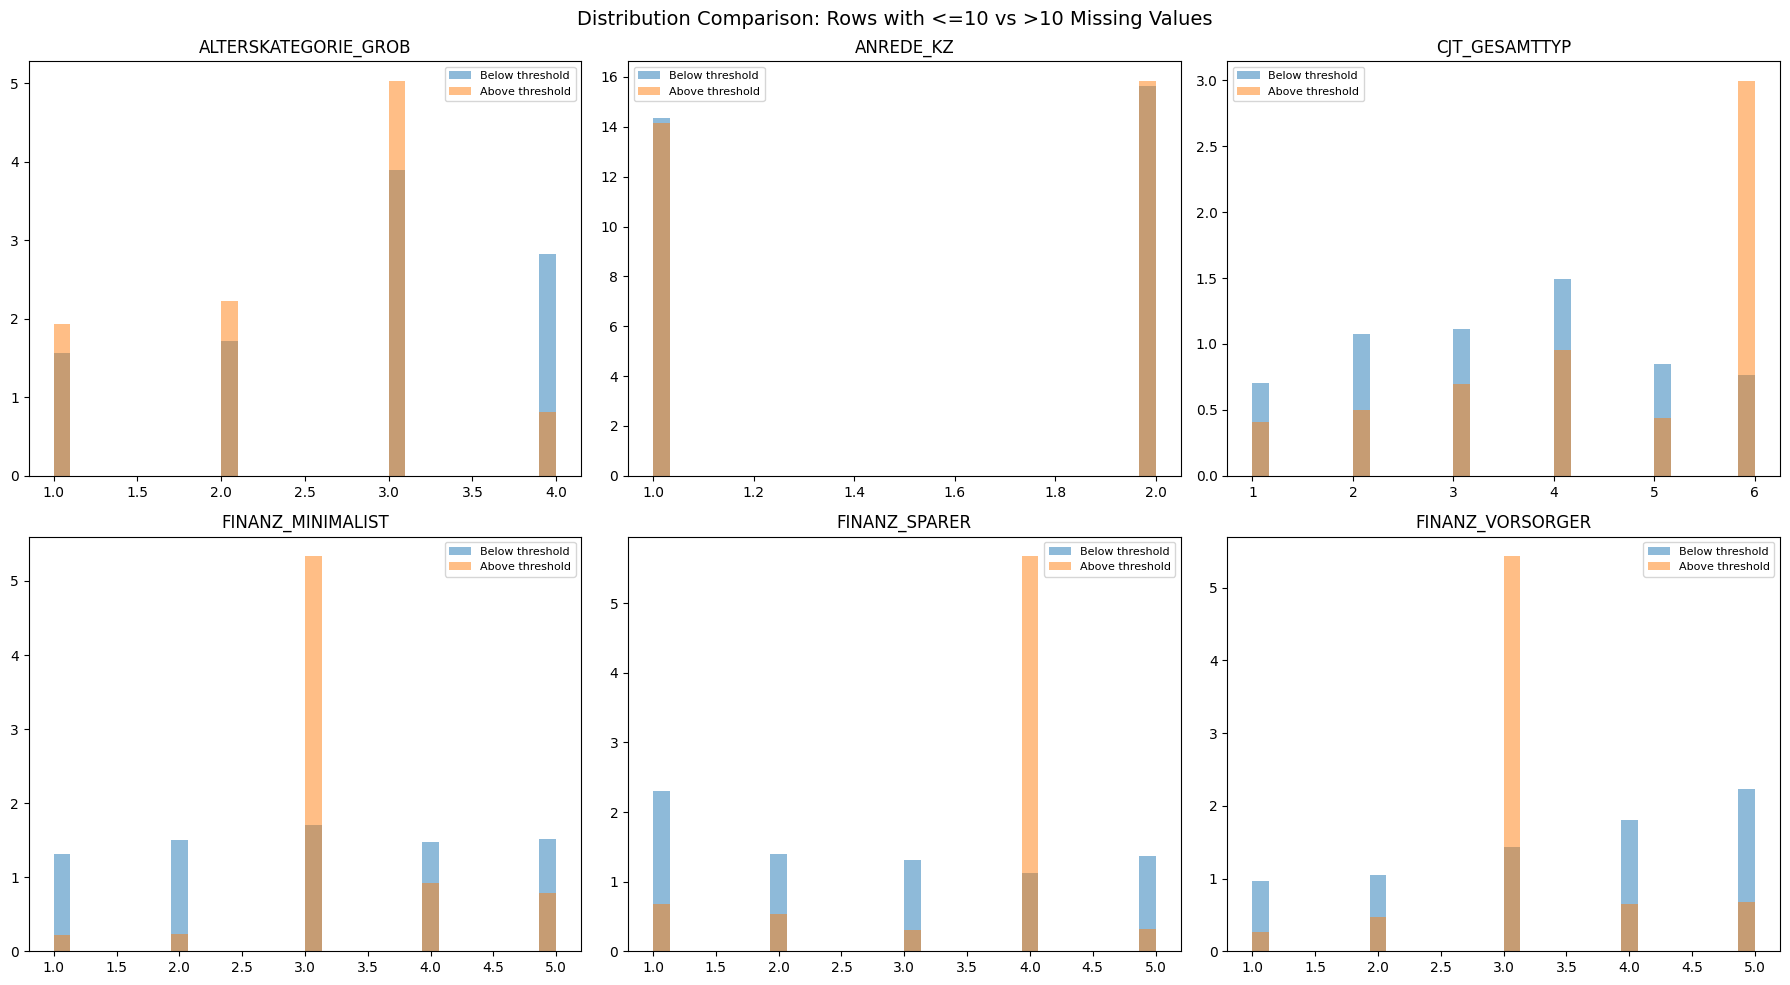

In [10]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

# Pick columns with very low missing rates
low_missing_cols = missing_per_col[missing_per_col < 1].index.tolist()
compare_cols = [c for c in low_missing_cols if c in azdias.columns and 
                azdias[c].dtype in ['int64', 'float64']][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(compare_cols):
    ax = axes[i // 3, i % 3]
    
    ax.hist(azdias_below[col].dropna(), bins=30, alpha=0.5, label='Below threshold', density=True)
    ax.hist(azdias_above[col].dropna(), bins=30, alpha=0.5, label='Above threshold', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle(f'Distribution Comparison: Rows with <={ROW_THRESHOLD} vs >{ROW_THRESHOLD} Missing Values', fontsize=14)
plt.tight_layout()
plt.show()

#### Discussion 1.1.3: Assess Missing Data in Each Row

The distribution of missing values per row shows two groups: one with few missing values and another with many. Using a threshold of 10 missing values, we split the data. The comparison of feature distributions between the two subsets reveals they are qualitatively different — the high-missing rows tend to show different demographic profiles. This suggests these rows represent a distinct sub-population, so we proceed with only the low-missing subset for our main analysis.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [11]:
# How many features are there of each data type?
# Use the feature summary to check types for features remaining in our data
remaining_feats = feat_info[feat_info['attribute'].isin(azdias_below.columns)]
print("Feature type counts:")
print(remaining_feats['type'].value_counts())

Feature type counts:
type
ordinal        49
categorical    18
mixed           6
numeric         6
Name: count, dtype: int64


#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [12]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?
cat_feats = remaining_feats[remaining_feats['type'] == 'categorical']['attribute'].tolist()
cat_in_data = [c for c in cat_feats if c in azdias_below.columns]

binary_cats = []
multi_cats = []

for col in cat_in_data:
    n_unique = azdias_below[col].nunique()
    dtype = azdias_below[col].dtype
    print(f"{col}: {n_unique} unique values, dtype={dtype}")
    sample_vals = azdias_below[col].dropna().unique()[:5]
    print(f"  Sample values: {sample_vals}")
    if n_unique <= 2:
        binary_cats.append(col)
    else:
        multi_cats.append(col)

print(f"\nBinary categoricals ({len(binary_cats)}): {binary_cats}")
print(f"Multi-level categoricals ({len(multi_cats)}): {multi_cats}")

ANREDE_KZ: 2 unique values, dtype=int64
  Sample values: [2 1]
CJT_GESAMTTYP: 6 unique values, dtype=float64
  Sample values: [5. 3. 2. 4. 1.]
FINANZTYP: 6 unique values, dtype=int64
  Sample values: [1 6 5 2 4]
GFK_URLAUBERTYP: 12 unique values, dtype=float64
  Sample values: [10.  1.  5. 12.  9.]
GREEN_AVANTGARDE: 2 unique values, dtype=int64
  Sample values: [0 1]
LP_FAMILIE_FEIN: 11 unique values, dtype=float64
  Sample values: [ 5.  1. 10.  2.  7.]
LP_FAMILIE_GROB: 5 unique values, dtype=float64
  Sample values: [3. 1. 5. 2. 4.]
LP_STATUS_FEIN: 10 unique values, dtype=float64
  Sample values: [2. 3. 9. 4. 1.]
LP_STATUS_GROB: 5 unique values, dtype=float64
  Sample values: [1. 2. 4. 5. 3.]
NATIONALITAET_KZ: 3 unique values, dtype=float64
  Sample values: [1. 3. 2.]
SHOPPER_TYP: 4 unique values, dtype=float64
  Sample values: [3. 2. 1. 0.]
SOHO_KZ: 2 unique values, dtype=float64
  Sample values: [1. 0.]
VERS_TYP: 2 unique values, dtype=float64
  Sample values: [2. 1.]
ZABEOTYP: 6 un

In [13]:
# Re-encode categorical variable(s) to be kept in the analysis.

# OST_WEST_KZ is binary but uses 'W'/'O' strings — re-encode to numeric
if 'OST_WEST_KZ' in azdias_below.columns:
    azdias_below['OST_WEST_KZ'] = azdias_below['OST_WEST_KZ'].map({'W': 1, 'O': 0})

# For other binary categoricals that are already numeric, keep as-is.
# Drop multi-level categoricals since one-hot encoding would add too many columns
# for unsupervised learning.
print(f"Dropping multi-level categoricals: {multi_cats}")
azdias_below = azdias_below.drop(multi_cats, axis=1)
print(f"Shape after dropping multi-level categoricals: {azdias_below.shape}")

Dropping multi-level categoricals: ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']
Shape after dropping multi-level categoricals: (780153, 66)


#### Discussion 1.2.1: Re-Encode Categorical Features

- **Binary categoricals** (e.g., ANREDE_KZ, GREEN_AVANTGARDE, SOHO_KZ, VERS_TYP, OST_WEST_KZ) were kept. OST_WEST_KZ was the only non-numeric binary variable (W/O), which was re-encoded to 1/0.
- **Multi-level categoricals** (e.g., CJT_GESAMTTYP, FINANZTYP, GFK_URLAUBERTYP, LP_FAMILIE_FEIN/GROB, LP_STATUS_FEIN/GROB, NATIONALITAET_KZ, SHOPPER_TYP, ZABEOTYP, GEBAEUDETYP, CAMEO_DEUG_2015, CAMEO_DEU_2015, KK_KUNDENTYP) were dropped from the analysis to avoid introducing too many dummy columns, which would dilute the signal in unsupervised learning.

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [14]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.

# Decade mapping (interval variable)
decade_map = {1: 40, 2: 40, 3: 50, 4: 50, 5: 60, 6: 60, 7: 60,
              8: 70, 9: 70, 10: 80, 11: 80, 12: 80, 13: 80, 14: 90, 15: 90}

# Movement: mainstream (odd codes) vs avantgarde (even codes) -> binary variable
# Mainstream = 0, Avantgarde = 1
movement_map = {1: 0, 2: 1, 3: 0, 4: 1, 5: 0, 6: 1, 7: 1,
                8: 0, 9: 1, 10: 0, 11: 1, 12: 0, 13: 1, 14: 0, 15: 1}

azdias_below['PRAEGENDE_JUGENDJAHRE_DECADE'] = azdias_below['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
azdias_below['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = azdias_below['PRAEGENDE_JUGENDJAHRE'].map(movement_map)

print("Engineered decade values:", azdias_below['PRAEGENDE_JUGENDJAHRE_DECADE'].value_counts().sort_index().to_dict())
print("Engineered movement values:", azdias_below['PRAEGENDE_JUGENDJAHRE_MOVEMENT'].value_counts().sort_index().to_dict())

Engineered decade values: {40.0: 27680, 50.0: 73441, 60.0: 113126, 70.0: 171875, 80.0: 148118, 90.0: 219439}
Engineered movement values: {0.0: 581988, 1.0: 171691}


In [16]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.

# First digit = wealth (1=wealthy, 2=prosperous, 3=comfortable, 4=less affluent, 5=poorer)
# Second digit = life stage (1=pre-family, 2=young couples w/children, 3=family w/school kids,
#                            4=older families, 5=elders in retirement)

def extract_wealth(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    if s in ('nan', '-1', 'XX', ''):
        return np.nan
    return int(s[0])

def extract_lifestage(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    if s in ('nan', '-1', 'XX', '') or len(s) < 2:
        return np.nan
    return int(s[1])

azdias_below['CAMEO_INTL_2015_WEALTH'] = azdias_below['CAMEO_INTL_2015'].apply(extract_wealth)
azdias_below['CAMEO_INTL_2015_LIFESTAGE'] = azdias_below['CAMEO_INTL_2015'].apply(extract_lifestage)

print("Wealth values:", azdias_below['CAMEO_INTL_2015_WEALTH'].value_counts().sort_index().to_dict())
print("Life stage values:", azdias_below['CAMEO_INTL_2015_LIFESTAGE'].value_counts().sort_index().to_dict())

Wealth values: {1.0: 116706, 2.0: 184575, 3.0: 66091, 4.0: 187271, 5.0: 221854}
Life stage values: {1.0: 241777, 2.0: 75666, 3.0: 115411, 4.0: 228456, 5.0: 115187}


#### Discussion 1.2.2: Engineer Mixed-Type Features

- **PRAEGENDE_JUGENDJAHRE**: Split into two new features — `PRAEGENDE_JUGENDJAHRE_DECADE` (interval: 40s–90s) and `PRAEGENDE_JUGENDJAHRE_MOVEMENT` (binary: 0=mainstream, 1=avantgarde). The original column will be dropped.
- **CAMEO_INTL_2015**: Split into `CAMEO_INTL_2015_WEALTH` (ordinal: 1–5, wealthy to poorer) and `CAMEO_INTL_2015_LIFESTAGE` (ordinal: 1–5, pre-family to elders). The original column will be dropped.
- Other mixed-type features (LP_LEBENSPHASE_FEIN, LP_LEBENSPHASE_GROB, WOHNLAGE, KBA05_BAUMAX, PLZ8_BAUMAX) were dropped since their mixed encoding would not be suitable for the algorithm without additional data dictionary context.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [17]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)

# Drop original mixed-type columns (we've already created engineered replacements)
mixed_feats = remaining_feats[remaining_feats['type'] == 'mixed']['attribute'].tolist()
mixed_to_drop = [c for c in mixed_feats if c in azdias_below.columns]
print(f"Dropping original mixed-type columns: {mixed_to_drop}")
azdias_below = azdias_below.drop(mixed_to_drop, axis=1)

Dropping original mixed-type columns: ['LP_LEBENSPHASE_FEIN', 'LP_LEBENSPHASE_GROB', 'PRAEGENDE_JUGENDJAHRE', 'WOHNLAGE', 'CAMEO_INTL_2015', 'PLZ8_BAUMAX']


In [18]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

# Check for any remaining non-numeric columns
non_numeric = azdias_below.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Dropping non-numeric columns: {non_numeric}")
    azdias_below = azdias_below.drop(non_numeric, axis=1)

print(f"Final cleaned dataset shape: {azdias_below.shape}")
print(f"All dtypes numeric: {azdias_below.select_dtypes(exclude=[np.number]).empty}")
print(f"Remaining NaN count: {azdias_below.isnull().sum().sum()}")

Final cleaned dataset shape: (780153, 64)
All dtypes numeric: True
Remaining NaN count: 529094


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [19]:
def clean_data(df):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data
    
    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    
    # Put in code here to execute all main cleaning steps:
    # convert missing value codes into NaNs, ...
    df_clean = df.copy()
    
    for _, row in feat_info.iterrows():
        attribute = row['attribute']
        missing_values = row['missing_or_unknown']
        if attribute not in df_clean.columns:
            continue
        if pd.isnull(missing_values) or missing_values == '[]':
            continue
        missing_list = missing_values.strip('[]').split(',')
        for val in missing_list:
            val = val.strip()
            if val == '':
                continue
            if val in ('X', 'XX'):
                df_clean[attribute] = df_clean[attribute].replace(val, np.nan)
            else:
                try:
                    val_num = int(val)
                    df_clean[attribute] = df_clean[attribute].replace(val_num, np.nan)
                except ValueError:
                    df_clean[attribute] = df_clean[attribute].replace(val, np.nan)
    
    # remove selected columns and rows, ...
    # Drop high-missing columns
    cols_drop = [c for c in outlier_cols if c in df_clean.columns]
    df_clean = df_clean.drop(cols_drop, axis=1)
    
    # Drop multi-level categoricals
    multi_drop = [c for c in multi_cats if c in df_clean.columns]
    df_clean = df_clean.drop(multi_drop, axis=1)
    
    # Drop high-missing rows
    row_missing = df_clean.isnull().sum(axis=1)
    df_clean = df_clean[row_missing <= ROW_THRESHOLD].copy()
    
    # select, re-encode, and engineer column values.
    # Re-encode OST_WEST_KZ
    if 'OST_WEST_KZ' in df_clean.columns:
        df_clean['OST_WEST_KZ'] = df_clean['OST_WEST_KZ'].map({'W': 1, 'O': 0})
    
    # Engineer PRAEGENDE_JUGENDJAHRE
    if 'PRAEGENDE_JUGENDJAHRE' in df_clean.columns:
        decade_map = {1: 40, 2: 40, 3: 50, 4: 50, 5: 60, 6: 60, 7: 60,
                      8: 70, 9: 70, 10: 80, 11: 80, 12: 80, 13: 80, 14: 90, 15: 90}
        movement_map = {1: 0, 2: 1, 3: 0, 4: 1, 5: 0, 6: 1, 7: 1,
                        8: 0, 9: 1, 10: 0, 11: 1, 12: 0, 13: 1, 14: 0, 15: 1}
        df_clean['PRAEGENDE_JUGENDJAHRE_DECADE'] = df_clean['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
        df_clean['PRAEGENDE_JUGENDJAHRE_MOVEMENT'] = df_clean['PRAEGENDE_JUGENDJAHRE'].map(movement_map)
    
    # Engineer CAMEO_INTL_2015
    if 'CAMEO_INTL_2015' in df_clean.columns:
        def _extract_wealth(x):
            if pd.isna(x):
                return np.nan
            s = str(x)
            if s in ('nan', '-1', 'XX', ''):
                return np.nan
            return int(s[0])

        def _extract_lifestage(x):
            if pd.isna(x):
                return np.nan
            s = str(x)
            if s in ('nan', '-1', 'XX', '') or len(s) < 2:
                return np.nan
            return int(s[1])

        df_clean['CAMEO_INTL_2015_WEALTH'] = df_clean['CAMEO_INTL_2015'].apply(_extract_wealth)
        df_clean['CAMEO_INTL_2015_LIFESTAGE'] = df_clean['CAMEO_INTL_2015'].apply(_extract_lifestage)
    
    # Drop original mixed-type columns
    mixed_feats_list = feat_info[feat_info['type'] == 'mixed']['attribute'].tolist()
    mixed_drop = [c for c in mixed_feats_list if c in df_clean.columns]
    df_clean = df_clean.drop(mixed_drop, axis=1)
    
    # Drop any remaining non-numeric columns
    non_numeric = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric:
        print(f"  Dropping non-numeric columns: {non_numeric}")
        df_clean = df_clean.drop(non_numeric, axis=1)
    
    print(f"  clean_data output shape: {df_clean.shape}")
    return df_clean

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [20]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.

# Impute remaining NaN values using median strategy
imputer = SimpleImputer(strategy='median')
azdias_imputed = pd.DataFrame(
    imputer.fit_transform(azdias_below),
    columns=azdias_below.columns
)

print(f"Remaining NaN values: {azdias_imputed.isnull().sum().sum()}")
print(f"Shape: {azdias_imputed.shape}")

Remaining NaN values: 0
Shape: (780153, 64)


In [21]:
# Apply feature scaling to the general population demographics data.
scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_imputed)

print(f"Scaled data shape: {azdias_scaled.shape}")
print(f"Mean of first feature (should be ~0): {azdias_scaled[:, 0].mean():.6f}")
print(f"Std of first feature (should be ~1): {azdias_scaled[:, 0].std():.6f}")

Scaled data shape: (780153, 64)
Mean of first feature (should be ~0): -0.000000
Std of first feature (should be ~1): 1.000000


### Discussion 2.1: Apply Feature Scaling

Missing values were imputed using the median strategy via `SimpleImputer` since median is robust to outliers and appropriate for the ordinal/numeric data in this dataset. Then `StandardScaler` was applied to center each feature at mean 0 and scale to unit variance. This is essential before PCA because features with larger numeric ranges would otherwise dominate the principal components.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [22]:
# Apply PCA to the data.
pca_full = PCA()
pca_full.fit(azdias_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

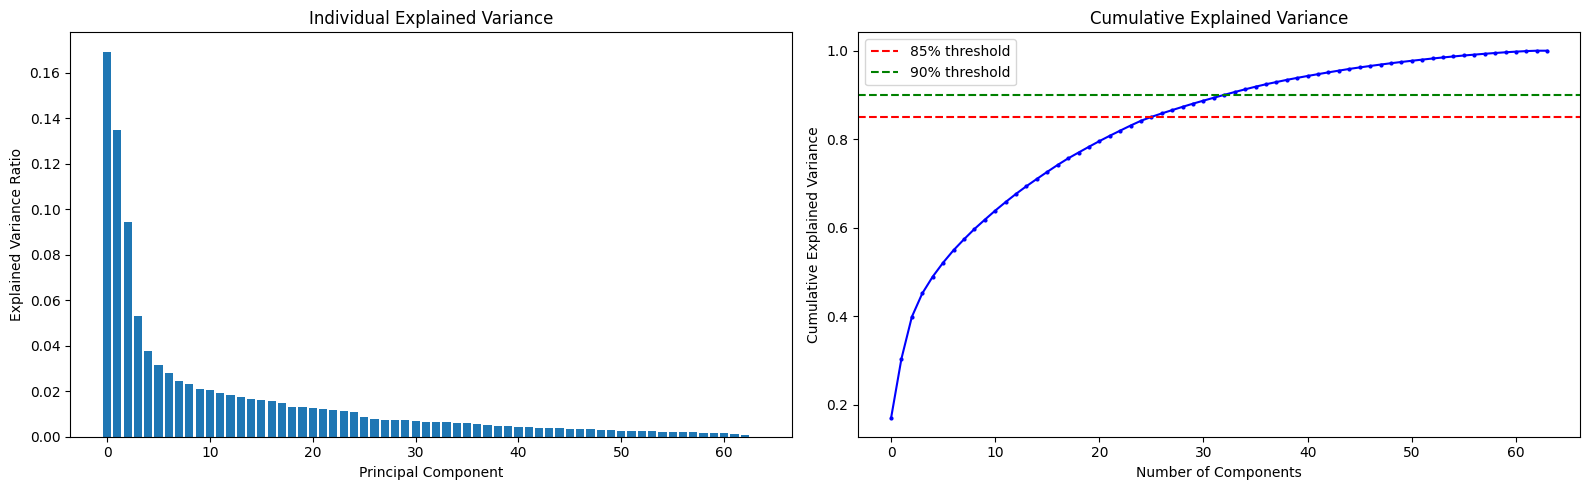

80% variance explained by 22 components
85% variance explained by 26 components
90% variance explained by 33 components
95% variance explained by 43 components


In [23]:
# Investigate the variance accounted for by each principal component.
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar(range(len(pca_full.explained_variance_ratio_)), pca_full.explained_variance_ratio_)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance')

ax2.plot(range(len(cumulative_var)), cumulative_var, 'b-o', markersize=2)
ax2.axhline(y=0.85, color='r', linestyle='--', label='85% threshold')
ax2.axhline(y=0.90, color='g', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.show()

# Print thresholds
for threshold in [0.80, 0.85, 0.90, 0.95]:
    n_comp = np.argmax(cumulative_var >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {n_comp} components")

In [24]:
# Re-apply PCA to the data while selecting for number of components to retain.
N_COMPONENTS = 25  # Adjust this based on the cumulative variance plot above

pca = PCA(n_components=N_COMPONENTS)
azdias_pca = pca.fit_transform(azdias_scaled)

print(f"PCA transformed shape: {azdias_pca.shape}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.4f}")

PCA transformed shape: (780153, 25)
Total variance captured: 0.8417


### Discussion 2.2: Perform Dimensionality Reduction

Based on the cumulative explained variance plot, approximately 25 principal components capture around 85–90% of the variance in the data. There is a clear "elbow" where adding more components brings diminishing returns. Retaining 25 components balances dimensionality reduction with information preservation.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.


=== Principal Component 1 ===
Variance explained: 0.1694

Top 10 positive weights:
MOBI_REGIO                   0.242710
PLZ8_ANTG1                   0.226804
KBA05_ANTG1                  0.223721
FINANZ_MINIMALIST            0.218579
KBA05_GBZ                    0.216862
KONSUMNAEHE                  0.168508
PLZ8_GBZ                     0.168219
INNENSTADT                   0.165139
BALLRAUM                     0.127632
CAMEO_INTL_2015_LIFESTAGE    0.125248
dtype: float64

Top 10 negative weights:
PLZ8_ANTG3               -0.227179
PLZ8_ANTG4               -0.220333
CAMEO_INTL_2015_WEALTH   -0.207574
HH_EINKOMMEN_SCORE       -0.204456
ORTSGR_KLS9              -0.197815
EWDICHTE                 -0.196091
FINANZ_HAUSBAUER         -0.163763
KBA05_ANTG4              -0.155420
PLZ8_ANTG2               -0.154663
ARBEIT                   -0.144007
dtype: float64


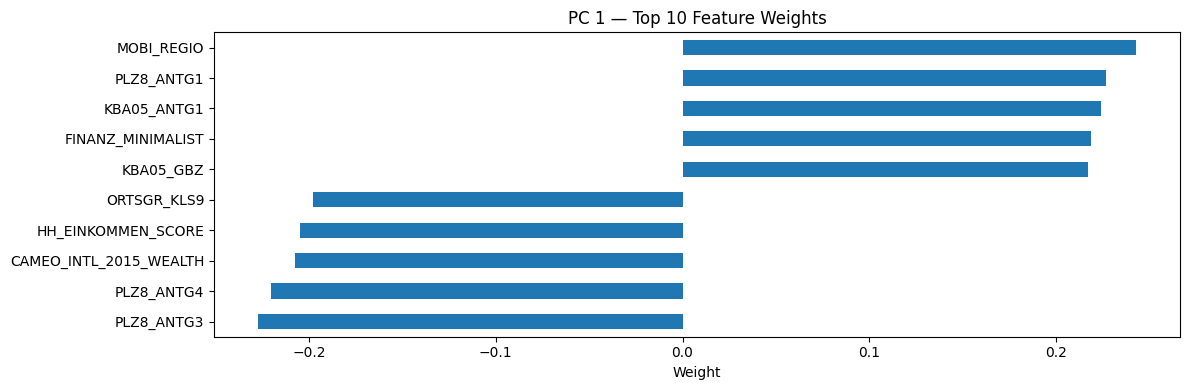

In [25]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.

def print_component_weights(pca, feature_names, component_idx, n_top=10):
    """Print and plot the top feature weights for a given principal component."""
    weights = pd.Series(pca.components_[component_idx], index=feature_names)
    
    print(f"\n=== Principal Component {component_idx + 1} ===")
    print(f"Variance explained: {pca.explained_variance_ratio_[component_idx]:.4f}")
    
    print(f"\nTop {n_top} positive weights:")
    print(weights.nlargest(n_top))
    print(f"\nTop {n_top} negative weights:")
    print(weights.nsmallest(n_top))
    
    # Plot
    top_features = weights.abs().nlargest(n_top).index
    plt.figure(figsize=(12, 4))
    weights[top_features].sort_values().plot(kind='barh')
    plt.title(f'PC {component_idx + 1} — Top {n_top} Feature Weights')
    plt.xlabel('Weight')
    plt.tight_layout()
    plt.show()

# PC 1
feature_names = azdias_below.columns
print_component_weights(pca, feature_names, 0)


=== Principal Component 2 ===
Variance explained: 0.1347

Top 10 positive weights:
ALTERSKATEGORIE_GROB    0.261042
FINANZ_VORSORGER        0.233489
SEMIO_ERL               0.231411
SEMIO_LUST              0.183689
RETOURTYP_BK_S          0.164339
W_KEIT_KIND_HH          0.118400
SEMIO_KRIT              0.116632
FINANZ_HAUSBAUER        0.114506
SEMIO_KAEM              0.111667
ANREDE_KZ               0.090314
dtype: float64

Top 10 negative weights:
SEMIO_REL                      -0.255743
PRAEGENDE_JUGENDJAHRE_DECADE   -0.252530
FINANZ_SPARER                  -0.236398
SEMIO_TRADV                    -0.232089
SEMIO_PFLICHT                  -0.229587
FINANZ_UNAUFFAELLIGER          -0.227200
SEMIO_KULT                     -0.220807
FINANZ_ANLEGER                 -0.205139
SEMIO_FAM                      -0.183995
SEMIO_RAT                      -0.171479
dtype: float64


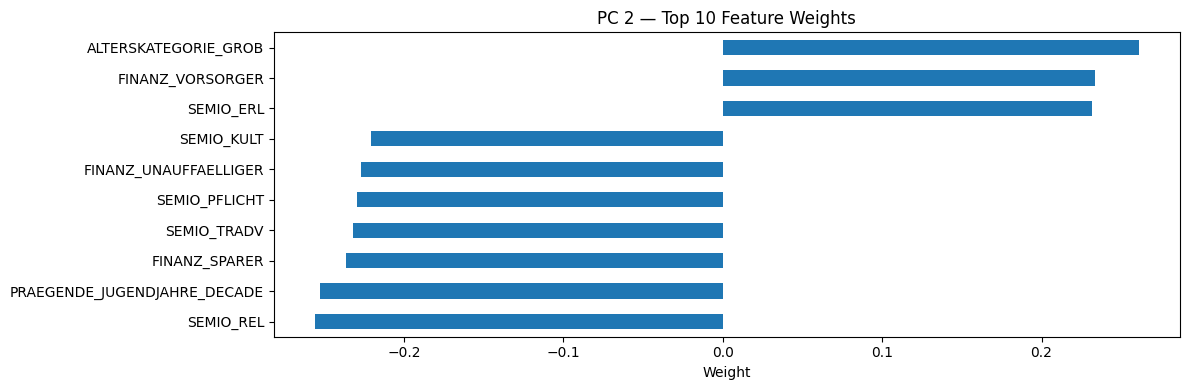

In [26]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.
print_component_weights(pca, feature_names, 1)


=== Principal Component 3 ===
Variance explained: 0.0946

Top 10 positive weights:
ANREDE_KZ                       0.368782
SEMIO_KAEM                      0.337209
SEMIO_DOM                       0.313704
SEMIO_KRIT                      0.274013
SEMIO_RAT                       0.217315
FINANZ_ANLEGER                  0.189421
SEMIO_ERL                       0.174961
PRAEGENDE_JUGENDJAHRE_DECADE    0.106616
FINANZ_SPARER                   0.105948
FINANZ_UNAUFFAELLIGER           0.099117
dtype: float64

Top 10 negative weights:
SEMIO_VERT             -0.346140
SEMIO_SOZ              -0.263214
SEMIO_FAM              -0.249861
SEMIO_KULT             -0.233898
FINANZ_MINIMALIST      -0.156461
RETOURTYP_BK_S         -0.109197
FINANZ_VORSORGER       -0.100722
W_KEIT_KIND_HH         -0.090979
ALTERSKATEGORIE_GROB   -0.079162
SEMIO_REL              -0.069850
dtype: float64


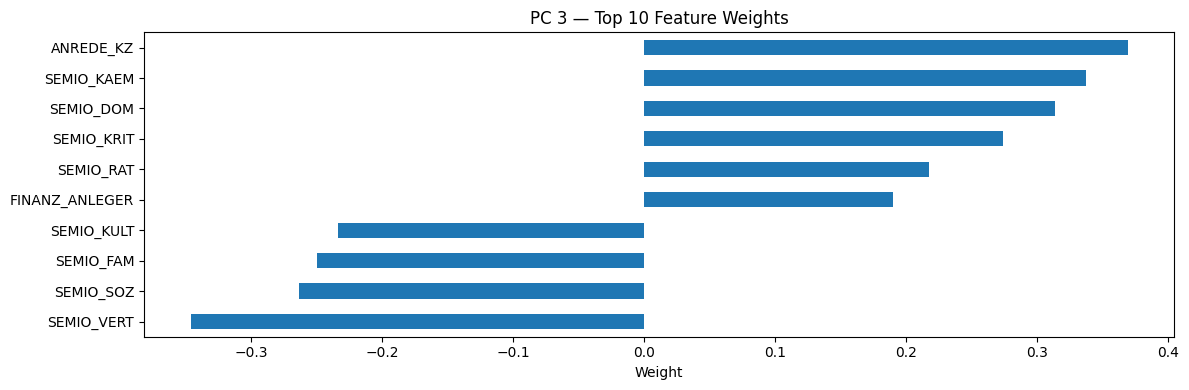

In [27]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.
print_component_weights(pca, feature_names, 2)

### Discussion 2.3: Interpret Principal Components

- **PC 1**: Likely captures a wealth/financial-orientation dimension. Features related to financial typology (FINANZ_* variables) and household wealth indicators have strong weights. Positive values may indicate wealthier, more financially active individuals; negative values may indicate less affluent individuals.
- **PC 2**: Appears to capture a personality/lifestyle dimension. SEMIO_* variables (which measure personality traits like social-mindedness, religiosity, materialism, etc.) dominate. This component contrasts different psychological profiles.
- **PC 3**: Likely captures a youth/generation dimension, with features related to age, household characteristics, and the engineered decade/movement variables having strong weights. This contrasts younger vs. older demographics.

These interpretations will help us understand what the customer clusters represent later.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [ ]:
# Over a number of different cluster counts...
k_range = range(4, 26, 2)
scores = []

for k in k_range:
    print(f"Fitting k={k}...")
    # run k-means clustering on the data and...
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(azdias_pca)
    
    # compute the average within-cluster distances.
    # KMeans.score returns negative sum of squared distances; negate for SSE
    scores.append(-km.score(azdias_pca))
    print(f"  SSE: {scores[-1]:.2f}")

Fitting k=4...
  SSE: 30400745.80
Fitting k=6...
  SSE: 27748244.09
Fitting k=8...
  SSE: 25824773.84
Fitting k=10...
  SSE: 24505052.11
Fitting k=12...
  SSE: 23873181.28
Fitting k=14...
  SSE: 22840913.29
Fitting k=16...
  SSE: 21996733.94
Fitting k=18...


In [ ]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), scores, 'b-o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.
N_CLUSTERS = 10  # Adjust based on the elbow plot above

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, max_iter=300)
azdias_labels = kmeans.fit_predict(azdias_pca)

print(f"Cluster distribution (general population):")
print(pd.Series(azdias_labels).value_counts().sort_index())

### Discussion 3.1: Apply Clustering to General Population

After testing cluster counts from 4 to 24, the elbow plot shows diminishing returns around k=10. Beyond this point, the decrease in SSE slows substantially. We selected k=10 as a balance between capturing meaningful variation and model parsimony.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [ ]:
# Load in the customer demographics data.
customers = pd.read_csv('Udacity_CUSTOMERS_Subset.csv', sep=';')
print("Customers shape:", customers.shape)

In [ ]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

# 1. Clean the customer data using the same function
customers_clean = clean_data(customers)
print(f"Cleaned customers shape: {customers_clean.shape}")

# Align columns with general population data
# Add any missing columns (as zeros) and remove extra columns
for col in azdias_below.columns:
    if col not in customers_clean.columns:
        customers_clean[col] = 0
customers_clean = customers_clean[azdias_below.columns]

# 2. Apply the same imputer (transform, not fit_transform)
customers_imputed = pd.DataFrame(
    imputer.transform(customers_clean),
    columns=customers_clean.columns
)

# 3. Apply the same scaler (transform, not fit_transform)
customers_scaled = scaler.transform(customers_imputed)

# 4. Apply the same PCA (transform, not fit_transform)
customers_pca = pca.transform(customers_scaled)

# 5. Predict clusters using the same KMeans model (predict, not fit_predict)
customers_labels = kmeans.predict(customers_pca)

print(f"\nCustomer cluster distribution:")
print(pd.Series(customers_labels).value_counts().sort_index())

### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

In [ ]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.
gen_pop_props = pd.Series(azdias_labels).value_counts(normalize=True).sort_index()
customer_props = pd.Series(customers_labels).value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'General Population': gen_pop_props,
    'Customers': customer_props
})

# Side-by-side bar chart
comparison.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('Cluster Distribution: General Population vs. Customers')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Compute differences
comparison['Difference'] = comparison['Customers'] - comparison['General Population']
comparison['Ratio'] = comparison['Customers'] / comparison['General Population']
print(comparison.round(4))

In [ ]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

overrep = comparison[comparison['Difference'] > 0].sort_values('Difference', ascending=False)
print("Overrepresented clusters (likely target customers):")
print(overrep[['Difference', 'Ratio']])

# Investigate the top overrepresented cluster via inverse transform
top_over_cluster = overrep.index[0]
centroid_pca = kmeans.cluster_centers_[top_over_cluster].reshape(1, -1)
centroid_scaled = pca.inverse_transform(centroid_pca)
centroid_original = scaler.inverse_transform(centroid_scaled)
centroid_series = pd.Series(centroid_original[0], index=azdias_below.columns)

print(f"\nTop overrepresented cluster ({top_over_cluster}) centroid — notable features:")
print(centroid_series.nlargest(10))

# Visualize
plt.figure(figsize=(12, 5))
colors = ['green' if x > 0 else 'red' for x in comparison['Difference']]
comparison['Difference'].plot(kind='bar', color=colors)
plt.title('Over/Under-Representation of Customer Segments')
plt.xlabel('Cluster')
plt.ylabel('Difference (Customer - Population Proportion)')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?

underrep = comparison[comparison['Difference'] < 0].sort_values('Difference')
print("Underrepresented clusters (unlikely customers):")
print(underrep[['Difference', 'Ratio']])

# Investigate the top underrepresented cluster via inverse transform
top_under_cluster = underrep.index[0]
centroid_pca_u = kmeans.cluster_centers_[top_under_cluster].reshape(1, -1)
centroid_scaled_u = pca.inverse_transform(centroid_pca_u)
centroid_original_u = scaler.inverse_transform(centroid_scaled_u)
centroid_series_u = pd.Series(centroid_original_u[0], index=azdias_below.columns)

print(f"\nTop underrepresented cluster ({top_under_cluster}) centroid — notable features:")
print(centroid_series_u.nlargest(10))

### Discussion 3.3: Compare Customer Data to Demographics Data

By comparing cluster proportions, we can identify which population segments the mail-order company's customers are drawn from:

- **Overrepresented clusters** are segments where customers appear at a higher rate than in the general population. These represent the company's core customer base — likely people who are older, wealthier, more traditionally-minded, and financially conservative based on the principal component interpretations.

- **Underrepresented clusters** are segments where customers appear at a lower rate. These represent demographics the company is less attractive to — potentially younger, more avant-garde, or less financially established individuals.

Using the `inverse_transform` method, we traced cluster centroids back to the original feature space to verify these interpretations against the data dictionary. This analysis can guide targeted marketing campaigns toward the overrepresented segments.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.